<a href="https://colab.research.google.com/github/karinenoronha/Agricultural-Material/blob/main/Churn_telco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

Upload **database**

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

Exploring data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#Checking if exist null values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
#convert churn rows to Y=1, N=0

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Análise Exploratória e Visualização Vamos começar importando matplotlib.pyplot e seaborn.

In [8]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib Inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'



Quantos clientes cancelaram?

In [9]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [10]:
# Qual a porcentagem de churn?
df.Churn.value_counts(normalize=True)*100

,proportion
Churn,
0,73.463013
1,26.536987


# **26,54% cancelaram o serviço**

**Q1. Tipo de contrato influencia o churn?**

In [11]:
pd.crosstab(df["Churn"], df["Contract"],normalize='index')*100

Contract,Month-to-month,One year,Two year
Churn,,,
0,42.906842,25.260920,31.832238
1,88.550027,8.881755,2.568218


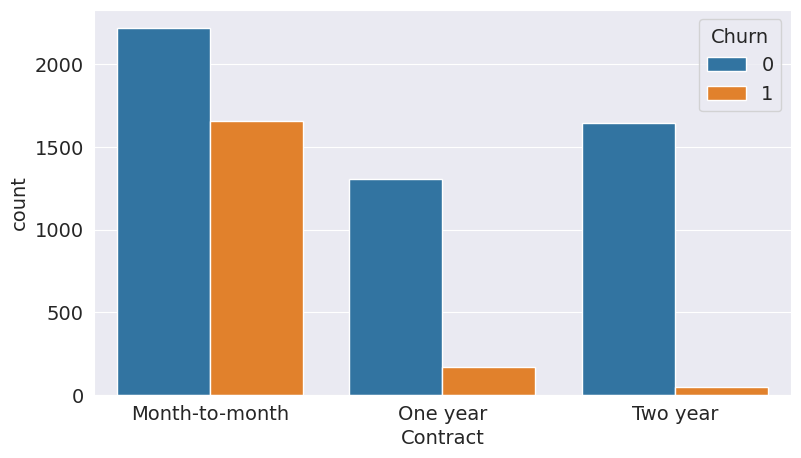

In [13]:
sns.countplot(data=df,x='Contract',hue='Churn')
plt.show()

Contrato mensal tem maior probabilidade de haver churn. Quanto maior o tipo de contrato, menor é a possibilidade de churn

## **Q2. Clientes novos cancelam mais?**

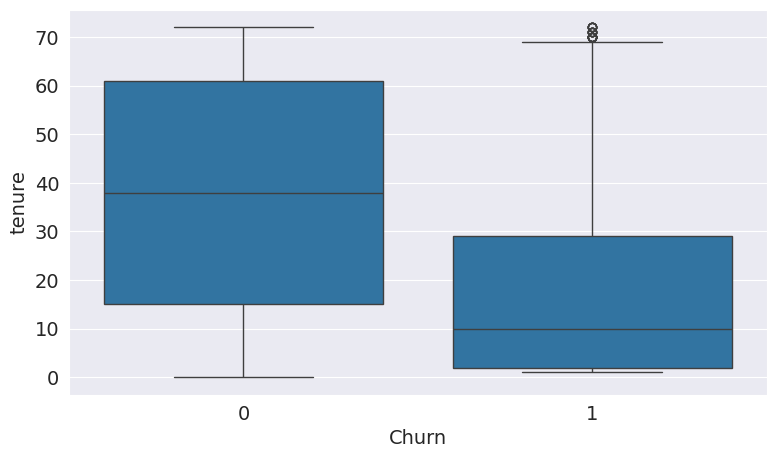

In [14]:
sns.boxplot(data=df,x='Churn',y='tenure')
plt.show()

os clientes com ternure menor, ou seja, clientes que possuem menor tempo de contrato, são os que fazem churn.




## Q4. Clientes mais caros cancelam mais?

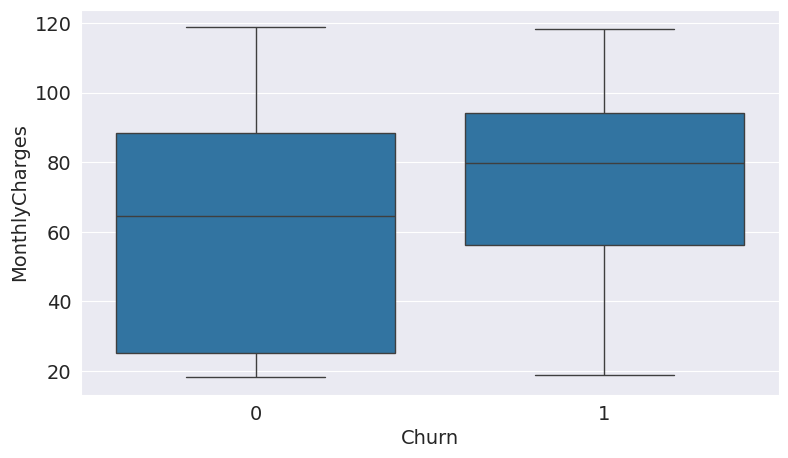

In [15]:
sns.boxplot(data=df,x='Churn',y='MonthlyCharges')
plt.show()

Segundo o grafico mostra que clientes com valores maiores acabam fazendo churn com mais frquencia

In [16]:
churn_yes = df[df['Churn'] == 1]
churn_no = df[df['Churn'] == 0]

#comparar medias
churn_yes = churn_yes['MonthlyCharges'].mean()
churn_no = churn_no['MonthlyCharges'].mean()

Q5. Qual serviço de internet mais comete churn?

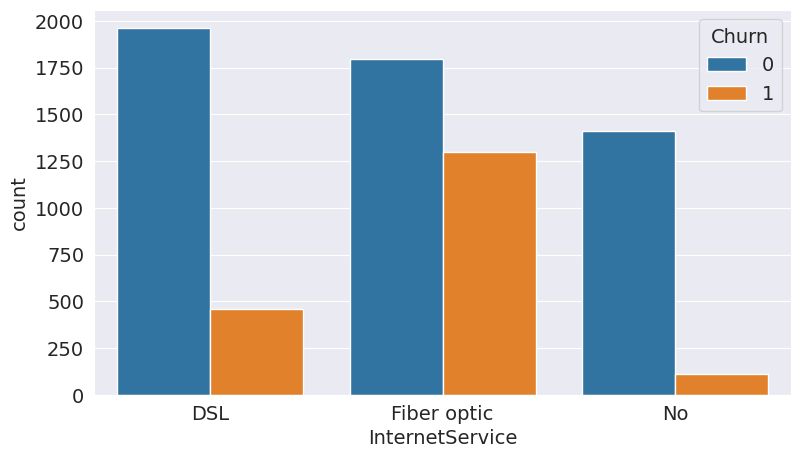

In [17]:
sns.countplot(data=df,x='InternetService',hue='Churn')
plt.show()

Serviço de internet de fibra otica é o que tem maior quantidade de churn

GRUPO DE RISCO DE CHURN

In [21]:
def risco_churn(row):
  if (row['Contract']=='Month-to-month') and (row['tenure']<12) and (row['MonthlyCharges']>70):
    return "Alto Risco"

  elif (row['Contract']=='Month-to-month') or (row['tenure']<12) :
    return "Medio Risco"

  else:
    "Baixo risco"

df['Segmento_Risco'] = df.apply(risco_churn,axis=1)

In [22]:
df['Segmento_Risco'].value_counts()

,count
Segmento_Risco,
Medio Risco,3222
Alto Risco,814


Visualizar por segmento:

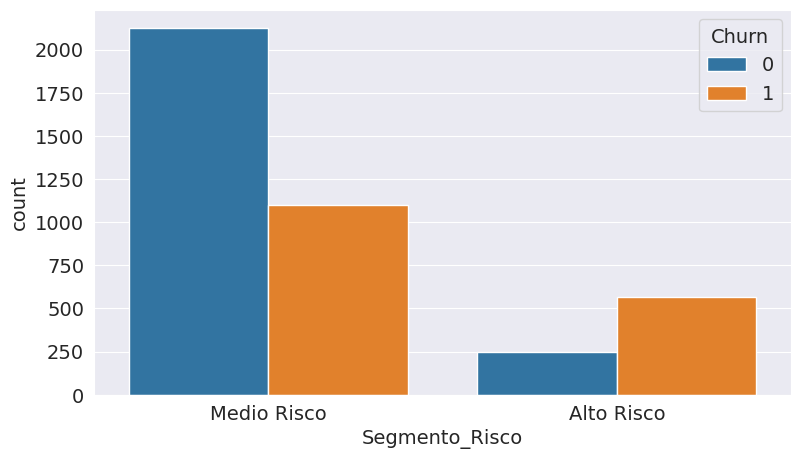

In [23]:
sns.countplot(data=df, x='Segmento_Risco', hue='Churn')
plt.show()

## **CONCLUSÃO:**


A segmentação dos clientes revelou três perfis de risco. O grupo de alto risco é composto principalmente por clientes com contrato mensal, baixo tempo de permanência e cobrança mensal elevada, apresentando maior taxa de churn. Já o grupo de baixo risco é formado por clientes com contratos de longo prazo e maior fidelização, o qual não existe contratos 100% seguros. Essa segmentação pode ser usada para estratégias de retenção focadas nos clientes mais vulneráveis.